# Notebook 2 : Sélection et évaluation de modèles

Notebook préparé par [Chloé-Agathe Azencott](http://cazencott.info) avec l'aide d'[Arthur Imbert](https://github.com/Henley13) et de [Giann Karlo](https://www.giannkarlo.info/).

Dans ce notebook il s'agit
* d'évaluer un modèle sur un jeu de test
* de choisir la valeur d'un hyperparamètre d'un algorithme d'apprentissage
* de comprendre l'intérêt de la régression polynomiale et de la régularisation

In [1]:
# load numpy as np, matplotlib as plt
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rc('font', **{'size': 12}) # règle la taille de police globalement pour les plots (en pt)

In [3]:
import pandas as pd

## 1. Chargement des données

#### Ormeau
Déterminer l'âge des ormeaux à partir de mesures physiques.  L'âge des ormeaux est déterminé en coupant la coquille à travers le cône, en la colorant et en comptant le nombre d'anneaux à l'aide d'un microscope, une tâche laborieuse et de longue durée.  D'autres mesures, plus faciles à obtenir, sont utilisées pour déterminer l'âge. Notre but est donc prédire l'âge des ormeaux de manière automatique et et aider les biologistes à déterminer l'âge des ormeaux dans un endroit donné. 

#### *Vin (optionnel)*
Nous allons travailler avec un jeu de données contenant des informations physico-chimiques sur un certain nombre de vins portugais (vinho verde), ainsi que les notes qui leur ont été attribuées par des gens qui les ont goûtés. Notre but est d'automatiser ce processus : nous voulons prédire directement la note des vins à partir de leurs caractéristiques physico-chimiques, afin d'assister les œnologues, améliorer la production de vin, et cibler les goûts de consomateurs de niche.

-----

Les deux jeux de données sont disponibles sur l'archive UCI de jeux de données de machine learning, sur laquelle vous trouverez de nombreux jeux de données classiques : [wine-quality](http://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/) et [abalone](https://archive.ics.uci.edu/dataset/1/abalone). Pas besoin de le télécharger, ils sont déjà dans votre répertoire, dans le fichier `data/abalone.csv` ou `data/winequality-white.csv`. Nous allons le charger avec pandas :

In [4]:
df = pd.read_csv('data/abalone.csv', # nom du fichier
                   sep="," # séparateur de colonnes
                   )

# df = pd.read_csv('data/winequality-white.csv', # nom du fichier
#                    sep="," # séparateur de colonnes
#                    )

__Alternativement :__ Si vous avez besoin de télécharger le fichier (par exemple sur colab) :

In [ ]:
#!wget https://raw.githubusercontent.com/chagaz/cp-ia-intro-ml-2022/main/2-Selection/data/winequality-white.csv
!wget https://raw.githubusercontent.com/ThomasWalter/CourseFoundationsML/SIA2025/Notebooks/2-Selection/data/abalone.csv

# df = pd.read_csv('winequality-white.csv', # nom du fichier
#                    sep=";" # séparateur de colonnes
#                    )

df = pd.read_csv('abalone.csv', # nom du fichier
                   sep="," # séparateur de colonnes
                   )

Nous pouvons maintenant examiner ce fichier directement dans notre notebook, par exemple en en regardant les premières lignes :

In [5]:
df.head()

,sex,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


### Transformation one-hot

In [6]:
# Créer un nouveau data frame où la colomne 'sex' est remplacée par son encodage 'one-hot'
df_dummies = pd.get_dummies(df, columns=['sex'])

In [7]:
df_dummies.head()

,length,diameter,height,whole-weight,shucked-weight,viscera-weight,shell-weight,rings,sex_F,sex_I,sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,False,True,False


### Création des matrices X et y de données

In [8]:
X = np.array(df_dummies.drop(columns=['rings']))

In [9]:
y = np.array(df['rings'])

In [10]:
print(X.shape, y.shape)

(4177, 10) (4177,)


__Question :__ Combien d'exemples d'apprentissage contiennent les données ? Combien de variables ?

**Réponse :**

Les données contiennent :
- **4 177 exemples d'apprentissage** (X.shape[0])
- **10 variables** (X.shape[1])

__Question :__ Que pensez-vous de l'utilisation d'une régression linéaire pour résoudre ce problème ?

**Réponse :**

La régression linéaire est appropriée pour ce problème car :

1. **Type de problème** : C'est un problème de **régression** (pas de classification) 
   - La variable cible `y` (nombre d'anneaux) est **continue**.
   - On veut prédire une valeur numérique, pas une classe.

2. **Simplicité et interprétabilité**
   - La régression linéaire est simple et facile à interpréter.
   - Les coefficients permettent de voir l'impact de chaque caractéristique sur l'âge.

3. **Bonnes performances attendues**
   - Il existe probablement une **relation à peu près linéaire** entre les mesures physiques et l'âge des ormeaux.
   - Les données ne montrent probablement pas de relations hautement non-linéaires.

La régression linéaire est un **bon point de départ** (baseline) pour ce problème. Elle est appropriée pour explorer et comprendre les données avant d'essayer des modèles plus complexes.

### Transformation en un problème de classification binaire

Nous allons essayer de classifier les anciens et les plus jeunes ormeaux (score >= 10).

In [11]:
y = np.where(y >= 10, 1, 0)

## 2. Séparation des données en un jeu d'entraînement et un jeu de test

Pour pouvoir évaluer un modèle d'apprentissage de façon non-biaisée, nous avons besoin de créer un jeu de test contenant des données sur lequel le modèle n'a pas été entraîné. Ce jeu de test correspond à des données « nouvelles ».

Pour ce faire, nous allons utiliser la fonction [train_test_split](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) du module `model_selection` de scikit-learn :

In [12]:
from sklearn import model_selection

X_train, X_test, y_train, y_test = \
    model_selection.train_test_split(X, y,
                                    test_size=0.3, # 30% des données dans le jeu de test
                                    random_state=42 # graine du générateur aléatoire
                                    )

Fixer la graine du générateur aléatoire nous permet d'obtenir les mêmes jeux d'entraînement et de test en relançant la commande.

In [13]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(2923, 10) (1254, 10) (2923,) (1254,)


__Question :__ Combien d'échantillons le jeu d'entraînement (X_train, y_train) contient-il ? Et le jeu de test (X_test, y_test) ?

**Réponse :**

D'après la division train/test avec `test_size=0.3`, les jeux contiennent :

**Jeu d'entraînement (X_train, y_train) :**
- **2923 échantillons** avec 10 variables.

**Jeu de test (X_test, y_test) :**
- **1254 échantillons** avec 10 variables.

### Transformation des variables
Nous avons vu dans le Notebook 1 qu'il est plus raisonnable de centrer-réduire les variables avant de procéder.

N'oublions pas que le jeu de test est prétendu non-connu au moment de l'entraînement : il faut utiliser __uniquement le jeu d'entraînement__ pour centrer-réduire les données.

In [14]:
from sklearn import preprocessing

In [15]:
# Créer un "standardiseur" et le calibrer sur les données d'entraînement
std_scaler = preprocessing.StandardScaler().fit(X_train)

# Appliquer la standardisation aux données d'entraînement
X_train_scaled = std_scaler.transform(X_train)

# Appliquer la standardisation aux données de test
X_test_scaled = std_scaler.transform(X_test)

## 3. Plus proches voisins

Nous allons maintenant évaluer la capacité d'un algorithme des plus proches voisins à classifier les ormeaux.

Pour cela, nous faisons appel à la classe [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) du module `neighbors` de scikit-learn.

In [16]:
from sklearn import neighbors

### Entrainement sur le jeu d'entrainement

Comme dans le Notebook 1, on commence par instancier un objet de la classe qui nous intéresse :

In [17]:
model_knn = neighbors.KNeighborsClassifier()

On peut ensuite l'entraîner sur les données d'entrainement centrées-réduites :

In [18]:
model_knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Prédictions sur le jeu de test

On peut maintenant utiliser le classifieur entraîné sur les données de test, toujours centrées-réduites :

In [19]:
y_pred_knn = model_knn.predict(X_test_scaled)

### Évaluation de la performance

De nombreuses métriques permettent d'évaluer la performance d'un algorithme de classification (voir [la doc de scikit-learn à ce sujet](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)). La __matrice de confusion__ en particulier permet de visualiser combien d'exemple de chaque classe reçoivent chacune des étiquettes :

In [20]:
from sklearn import metrics

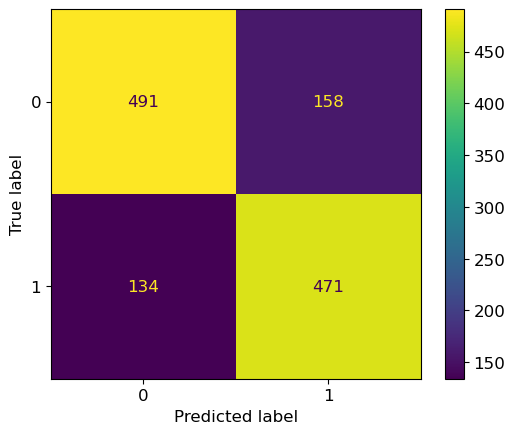

In [21]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn)

La matrice de confusion peut être résumée par le [score F1](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score).

Le **score F1** est utile pour évaluer les performances d'un modèle de classification. Il combine deux autres mesures importantes : la **precision** et le **recall**. Le score F1 est la moyenne harmonique de la precision et du recall, fournissant un score unique qui équilibre les deux.

Le score F1 est utile lorsque vous disposez d'un ensemble de données déséquilibré, par exemple un ensemble de données sur la **désinformation** où 99 % des publications ne sont pas fausses et seulement 1 % le sont. Un modèle qui prédit simplement « non faux » à chaque fois serait précis à 99 %, mais il serait inutile car il ne trouverait jamais les fausses informations. Le score F1 fournit une bien meilleure évaluation dans ces cas-là.

In [22]:
print("F1 du kNN sur le jeu de test : %.3f" % metrics.f1_score(y_test, y_pred_knn))

F1 du kNN sur le jeu de test : 0.763


## 4. Sélection du nombre de plus proches voisins

__Question :__ Combien de plus proches voisins a-t-on utilisé dans la section précédente ? Appuyez-vous sur la documentation, par exemple en tapant
```
 help(neighbors.KNeighborsClassifier)
 ```
dans une cellule ci-dessous.

In [23]:
help(neighbors.KNeighborsClassifier)

Help on class KNeighborsClassifier in module sklearn.neighbors._classification:

class KNeighborsClassifier(sklearn.neighbors._base.KNeighborsMixin, sklearn.base.ClassifierMixin, sklearn.neighbors._base.NeighborsBase)
 |  KNeighborsClassifier(
 |      n_neighbors=5,
 |      *,
 |      weights='uniform',
 |      algorithm='auto',
 |      leaf_size=30,
 |      p=2,
 |      metric='minkowski',
 |      metric_params=None,
 |      n_jobs=None
 |  )
 |
 |  Classifier implementing the k-nearest neighbors vote.
 |
 |  Read more in the :ref:`User Guide <classification>`.
 |
 |  Parameters
 |  ----------
 |  n_neighbors : int, default=5
 |      Number of neighbors to use by default for :meth:`kneighbors` queries.
 |
 |  weights : {'uniform', 'distance'}, callable or None, default='uniform'
 |      Weight function used in prediction.  Possible values:
 |
 |      - 'uniform' : uniform weights.  All points in each neighborhood
 |        are weighted equally.
 |      - 'distance' : weight points by 

### Mise en place d'une validation croisée

Le nombre de plus proches voisins (`n_neighbors`) est un __hyperparamètre__ de l'algorithme des plus proches voisins : il ne fait pas partie des paramètres du modèle appris par l'algorithme, mais nous devons le fixer nous-mêmes avant l'entraînement.

Nous allons maintenant _choisir_ ce nombre de plus proches voisins par une procédure de __recherche en grille__ (_gridsearch_), qui consiste à _comparer_ les performances de modèles entraînés en utilisant des valeurs prédéfinies (la grille) de l'hyperparamètre. 

Attention ! Si nous voulons pouvoir utiliser le jeu de test pour évaluer l'erreur de généralisation du modèle utilisant la valeur optimale du nombre de plus proches voisins, nous ne pouvons pas l'utiliser aussi pour cette étape de sélection, car sinon nous pourrions biaiser le modèle et surapprendre.

Pour comparer nos modèles __sur le jeu d'entraînement__, nous allons utiliser une __validation croisée__, encore une fois grâce au module [model-selection](http://scikit-learn.org/stable/model_selection.html#model-selection) de scikit-learn.

In [24]:
n_folds = 10

# Créer un objet KFold qui permettra de cross-valider en n_folds folds
kf = model_selection.KFold(n_splits=n_folds,  
                           shuffle=True, # mélanger les échantillons avant de créer les folds
                           random_state=42 # graine pour le mélange des échantillons et pour la reproductibilité
                          )

# Utiliser kf pour partager le jeu d'entraînement en n_folds folds. 
# kf.split retourne un iterateur (consommé après une boucle).
# Pour pouvoir se servir plusieurs fois des mêmes folds, nous transformons cet itérateur en liste d'indices :
kf_indices = list(kf.split(X_train))

`kf_indices` contient 10 paires de deux vecteurs d'indices. 

Chacune de ces paires correspond à un fold. 

Le premier vecteur donne les indices des échantillons formant la partie entraînement de ce fold. Le deuxième donne les indices des échantillons formant la partie test de ce fold.

In [25]:
for (idx, fold) in enumerate(kf_indices):
    print("Le fold %d contient %d observations pour l'entraînement and %d observations pour la validation" % (idx, len(fold[0]), len(fold[1])))

Le fold 0 contient 2630 observations pour l'entraînement and 293 observations pour la validation
Le fold 1 contient 2630 observations pour l'entraînement and 293 observations pour la validation
Le fold 2 contient 2630 observations pour l'entraînement and 293 observations pour la validation
Le fold 3 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 4 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 5 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 6 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 7 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 8 contient 2631 observations pour l'entraînement and 292 observations pour la validation
Le fold 9 contient 2631 observations pour l'entraînement and 292 observations pour la validation


__Question :__ Combien de fois chaque échantillon apparaît-il dans la partie entraînement d'un fold ? Dans la partie test ? (Il n'est pas nécessaire d'écrire de code pour répondre.)

**Réponse :**

Pour une validation croisée en k folds :

- Chaque échantillon apparaît **exactement 1 fois** dans la partie test (au cours des k itérations).
- Chaque échantillon apparaît **k − 1 fois** dans la partie entraînement (une fois pour chaque fold où il n'est pas dans le test).

Dans ce notebook `n_folds = 10`, donc :

- Apparitions dans la partie test : **1 fois**
- Apparitions dans la partie entraînement : **9 fois**

### Recherche en grille

Nous allons commencer par définir une __grille__ de valeurs d'hyperparamètres, c'est à dire une liste de valeurs du nombre de plus proches voisins à évaluer :

In [26]:
k_values = np.arange(3, 50, step=2)

In [27]:
k_values

array([ 3,  5,  7,  9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35,
       37, 39, 41, 43, 45, 47, 49])

__Question :__ Pourquoi sélectionner uniquement des nombres impairs de voisins ?

**Réponse :**

On choisit en général des valeurs impaires pour le nombre de voisins `k` en classification (k-NN) pour éviter les égalités lors du vote majoritaire.

- Dans une classification binaire, si `k` est pair, il est possible d'avoir un vote ex æquo (par exemple 2 voisins de la classe 0 et 2 de la classe 1 pour `k=4`), ce qui oblige à appliquer une règle de départage (tie-breaking) arbitraire.
- Si `k` est impair, un seul des deux groupes peut obtenir strictement la majorité (p. ex. 3 vs 2 pour `k=5`), donc le vote majoritaire est unique et la décision est plus simple et stable.

Remarques :
- Pour des problèmes à plus de deux classes, des égalités peuvent toujours survenir même pour `k` impair, mais l'usage d'`k` impair réduit la fréquence des égalités pour des problèmes binaires.
- On peut aussi utiliser d'autres méthodes pour gérer les égalités : pondérer les voisins par la distance (voisin le plus proche pèse plus), utiliser une règle de priorité sur les classes, ou appliquer un tie-break basé sur la distance moyenne.

Conclusion : privilégier un `k` impair est une règle pratique simple pour minimiser les égalités de vote en classification binaire, mais ce n'est pas une obligation fondamentale si vous utilisez un tie-break raisonnable ou un poids par distance.

Nous allons maintenant utiliser la classe [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) du module `model_selection` de scikit-learn pour déterminer la valeur optimale du nombre de plus proches voisins par recherche en grille :

In [28]:
# Instanciation d'un objet GridSearchCV
grid = model_selection.GridSearchCV(neighbors.KNeighborsClassifier(), # prédicteur à évaluer
                                    {'n_neighbors':k_values}, # dictionnaire de valeurs d'hyperparamètres
                                    cv=kf_indices, # validation croisée à utiliser
                                    scoring='f1' # métrique d'évaluation de la performance
                                   )

Nous allons aussi utiliser la [commande magique time](https://ipython.readthedocs.io/en/stable/interactive/magics.html) pour mesurer le temps de calcul d'une cellule de notre notebook.

In [29]:
%%time
# Utilisation de cet objet sur les données d'entraînement (centrées-réduites)
grid.fit(X_train_scaled, y_train)

CPU times: user 2.88 s, sys: 0 ns, total: 2.88 s
Wall time: 2.88 s


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 3, 5..., 45, 47, 49])}"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,"[(array([ 0, ...shape=(2630,)), ...), (array([ 0, ...shape=(2630,)), ...), ...]"
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(23)


La valeur optimale de l'hyperparamètre est donnée par :

In [30]:
print(grid.best_params_)

{'n_neighbors': np.int64(23)}


Le code suivant permet d'afficher la performance du modèle selon la valeur de l'hyperparamètre :

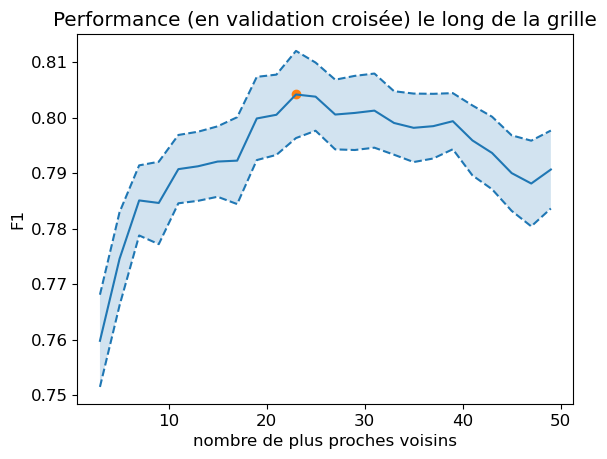

In [31]:
mean_test_score = grid.cv_results_['mean_test_score']
stde_test_score = grid.cv_results_['std_test_score'] / np.sqrt(n_folds) # standard error

p = plt.plot(k_values, mean_test_score)
plt.plot(k_values, (mean_test_score + stde_test_score), '--', color=p[0].get_color())
plt.plot(k_values, (mean_test_score - stde_test_score), '--', color=p[0].get_color())
plt.fill_between(k_values, (mean_test_score + stde_test_score), 
                 (mean_test_score - stde_test_score), alpha=0.2)

best_index = np.where(k_values == grid.best_params_['n_neighbors'])[0][0]
plt.scatter(k_values[best_index], mean_test_score[best_index])


plt.xlabel('nombre de plus proches voisins')
plt.ylabel('F1')
plt.title("Performance (en validation croisée) le long de la grille")
plt.show()

### Modèle optimal de plus proches voisins

In [32]:
print("Meilleur F1 en validation croisée : %.3f" % grid.best_score_)

Meilleur F1 en validation croisée : 0.804


Le modèle entraîné sur l'intégralité des données fournies à `grid.fit` avec la (les) meilleure(s) valeur(s) d'hyperparamètre(s) est donné par `grid.best_estimator_`.

In [33]:
y_pred_knn_opt = grid.best_estimator_.predict(X_test_scaled)

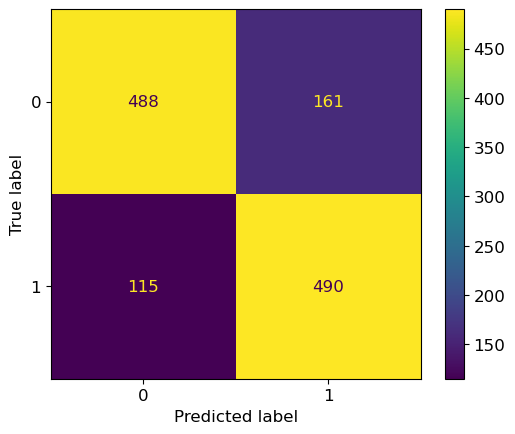

In [34]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_opt)

In [35]:
print(metrics.confusion_matrix(y_test, y_pred_knn_opt))

[[488 161]
 [115 490]]


Version alternative (ancienne version de scikit-learn) :

In [36]:
print("F1 du kNN (k optimal) sur le jeu de test : %.3f" % metrics.f1_score(y_test, y_pred_knn_opt))

F1 du kNN (k optimal) sur le jeu de test : 0.780


## 5. Régression logistique régularisée

### Performance d'une régression logistique non-régularisée

Nous allons maintenant entraîner une régression __logistique__ (car nous avons un problème de classification) _sur le jeu d'entraînement_ et l'évaluer _sur le jeu de test_.

Nous utilisons la classe [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) du module `linear_model` de scikit-learn.

In [37]:
from sklearn import linear_model

In [38]:
# Créer un modèle de régression linéaire 
model_rlog = linear_model.LogisticRegression(penalty=None # modèle non régularisé pour l'instant
                                            )

# Entraîner ce modèle sur (X_train_scaled, y_train)
model_rlog.fit(X_train_scaled, y_train)

,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [39]:
# Prédire les étiquettes du jeu de test
y_pred_rlog = model_rlog.predict(X_test_scaled)

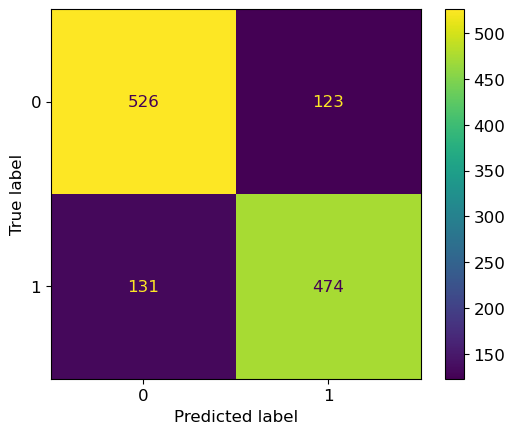

In [40]:
metrics.ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rlog)

In [41]:
print("F1 d'une régression logistique sur le jeu de test : %.3f" % metrics.f1_score(y_test, y_pred_rlog))

F1 d'une régression logistique sur le jeu de test : 0.789


__Question :__ Que pensez-vous de la qualité du modèle ?

**Réponse :**

Pour juger de la qualité du modèle, on regarde d'abord les métriques (ici le score F1 affiché) et la matrice de confusion. Voici comment interpréter et compléter l'analyse :

- Interprétation directe :
  - Si le F1 est **faible** (par exemple < 0.5) : le modèle a une mauvaise qualité pour la tâche (faible compromis précision/rappel).
  - Si le F1 est **moyen** (≈ 0.5–0.7) : le modèle capture partiellement la structure, mais il y a de la marge d'amélioration.
  - Si le F1 est **élevé** (> 0.7–0.8) : bonne performance relative (selon le problème et le déséquilibre des classes).

- Vérifications complémentaires à faire :
  - Regarder la **matrice de confusion** pour voir quels types d'erreurs sont commis (faux positifs vs faux négatifs).
  - Examiner **precision** et **recall** séparément : un F1 satisfaisant peut masquer un recall trop faible ou une precision trop faible selon l'application.
  - Vérifier **la variabilité** via validation croisée (est-ce que la performance est stable ?).
  - Tenir compte du **déséquilibre de classes** : si une classe est majoritaire, l'accuracy peut être trompeuse.
  - Tester des améliorations possibles : régularisation, features supplémentaires, modèles non linéaires, pondération des classes ou KNN pondéré par distance.

- Conclusion pratique (exemple) :
  - Si le F1 affiché pour la régression logistique est proche de celui du k-NN (0.78), alors la qualité est **raisonnable** et le modèle linéaire est acceptable comme baseline.
  - Si le F1 est nettement inférieur à celui d'autres modèles, alors le modèle actuel **n'est pas satisfaisant** et il faut explorer d'autres approches (polynomial, arbres, réglage d'hyperparamètres).

En résumé : interpréter le F1 affiché dans son contexte (matrice de confusion, coûts des erreurs, variabilité) et utiliser ces éléments pour décider si le modèle est suffisant ou si des améliorations sont nécessaires.

### Coefficients du modèle

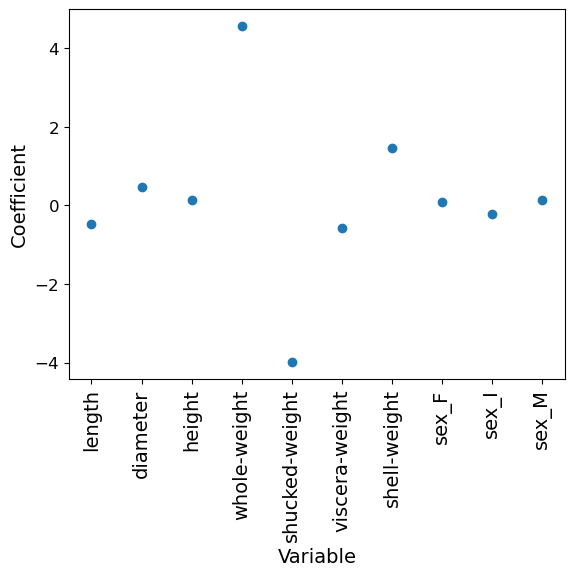

In [42]:
# Calculer le nombre de variables
num_features = X_train.shape[1]

# Afficher pour chaque variable son coefficient dans le modèle
plt.scatter(range(num_features), # en abcisse : indices des variables
            model_rlog.coef_ # en ordonnées : leur poids dans le modèle
           )

# Étiqueter les graduations de l'axe des abcsisses
tmp = plt.xticks(range(num_features), # une marque par variable
                 list(df_dummies.drop(columns=['rings']).columns),  # afficher le nom de la variable
                 rotation=90, # tourner les étiquettes de 90 degrés
                 fontsize=14)

# Étiqueter les axes
tmp = plt.xlabel('Variable', fontsize=14)
tmp = plt.ylabel('Coefficient', fontsize=14)
plt.show()

In [43]:
# Afficher les coefficients avec leurs noms de variables correspondants
for i, col_name in enumerate(df_dummies.drop(columns=['rings']).columns):
    print(f"{col_name}: {model_rlog.coef_[0][i]:.4f}")

length: -0.4844
diameter: 0.4712
height: 0.1382
whole-weight: 4.5643
shucked-weight: -3.9831
viscera-weight: -0.5650
shell-weight: 1.4623
sex_F: 0.0886
sex_I: -0.2200
sex_M: 0.1267


### Régularisation ridge

Nous allons maintenant ajouter une régularisation l2 (ou ridge) à cette régression logistique.

Ici il y a peu de variables et leurs coefficients prennent des valeurs faibles : il n'est pas certain que la régularisation soit nécessaire, mais comme ce jeu de données comporte peu de variables, nous pouvons l'utiliser pour regarder l'effet de la régularisation sur les valeurs des coefficients du modèle appris.

Commençons par nous donner une grille de valeurs pour le paramètre de régularisation `C`. 

Attention ! Plus `C` est grand, _moins_ il y a de régularisation. 

In [44]:
c_values = np.logspace(-6, 6, 50)
c_values

array([1.00000000e-06, 1.75751062e-06, 3.08884360e-06, 5.42867544e-06,
       9.54095476e-06, 1.67683294e-05, 2.94705170e-05, 5.17947468e-05,
       9.10298178e-05, 1.59985872e-04, 2.81176870e-04, 4.94171336e-04,
       8.68511374e-04, 1.52641797e-03, 2.68269580e-03, 4.71486636e-03,
       8.28642773e-03, 1.45634848e-02, 2.55954792e-02, 4.49843267e-02,
       7.90604321e-02, 1.38949549e-01, 2.44205309e-01, 4.29193426e-01,
       7.54312006e-01, 1.32571137e+00, 2.32995181e+00, 4.09491506e+00,
       7.19685673e+00, 1.26485522e+01, 2.22299648e+01, 3.90693994e+01,
       6.86648845e+01, 1.20679264e+02, 2.12095089e+02, 3.72759372e+02,
       6.55128557e+02, 1.15139540e+03, 2.02358965e+03, 3.55648031e+03,
       6.25055193e+03, 1.09854114e+04, 1.93069773e+04, 3.39322177e+04,
       5.96362332e+04, 1.04811313e+05, 1.84206997e+05, 3.23745754e+05,
       5.68986603e+05, 1.00000000e+06])

Nous allons maintenant utiliser non pas `GridSearchCV` mais implémenter notre recherche en grille nous-mêmes, afin d'avoir accès aux valeurs des coefficients de chacun des modèles :

In [45]:
%%time

f1_per_c = [] # pour enregistrer les valeurs du score F1 pour chacune des 50 valeurs de C
weights_per_c = [] # pour enregistrer les coefficients associés à chaque variable,  
                   # pour les 50 valeurs de C
for c_val in c_values:
    # Créer un modèle de régression logistique régularisée par le paramètre c_val
    model_ridge = linear_model.LogisticRegression(penalty='l2', C=c_val)
    
    # Calculer la performance en validation croisée du modèle
    f1 = model_selection.cross_val_score(model_ridge, # prédicteur à évaluer
                                         X_train_scaled, y_train, # données d'entrainement
                                         cv=kf_indices, # validation croisée à utiliser
                                         scoring='f1' # métrique d'évaluation de la performance
                                         )
    f1_per_c.append(f1)
    
    # Entrainer le modèle sur le jeu d'entrainement total 
    model_ridge.fit(X_train_scaled, y_train)
    
    # Enregistrer les coefficients de régression 
    weights_per_c.append(model_ridge.coef_[0])

CPU times: user 1min 16s, sys: 208 ms, total: 1min 17s
Wall time: 11.4 s


### Évolution de la performance en fonction du coefficient de régularisation

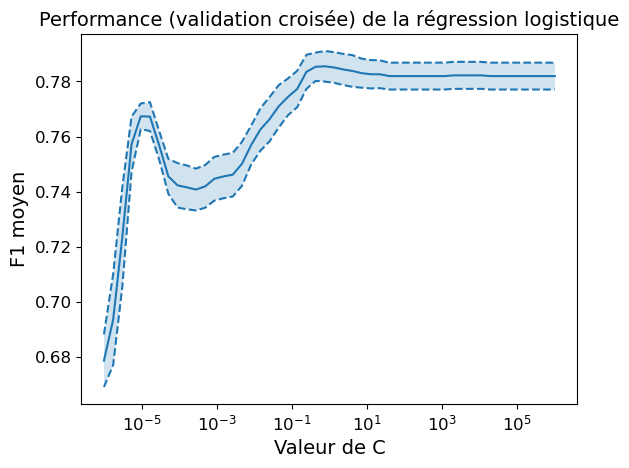

In [46]:
mean_test_score = np.mean(np.array(f1_per_c), axis=1)
stde_test_score = np.std(np.array(f1_per_c), axis=1) / np.sqrt(n_folds) # standard error

p = plt.plot(c_values, mean_test_score)
plt.plot(c_values, (mean_test_score + stde_test_score), '--', 
         color=p[0].get_color()) # réutiliser la même couleur que précédemment au lieu d'avancer
plt.plot(c_values, (mean_test_score - stde_test_score), '--', color=p[0].get_color())
plt.fill_between(c_values, (mean_test_score + stde_test_score), 
                 (mean_test_score - stde_test_score), alpha=0.2)


plt.xscale('log') # utiliser une échelle logarithmique en abcisse

# Étiqueter les axes
tmp = plt.xlabel('Valeur de C', fontsize=14)
tmp = plt.ylabel('F1 moyen', fontsize=14)

# Titre
tmp = plt.title("Performance (validation croisée) de la régression logistique", fontsize=14)
plt.show()

__Question :__ Comment l'erreur du modèle (en validation croisée) évolue-t-elle en fonction de la quantité de régularisation ?

**Réponse :**

En régression logistique scikit-learn, le paramètre `C` est **l'inverse du coefficient de régularisation**. Donc :
- **C grand**: Régularisation **faible**, le modèle s'ajuste davantage aux données d'entraînement.
- **C petit**: Régularisation **forte**, le modèle est plus pénalisé.

En fonction de C (ou de manière équivalente, en fonction de la force de la régularisation) :

1. **Pour C très petit (régularisation très forte)** :
   - Le modèle est trop pénalisé, trop conservateur.
   - Performance médiocre (biais élevé, sous-apprentissage).
   - F1 faible, l'erreur est plus grand.

2. **Pour C intermédiaire (régularisation modérée)** :
   - **Optimal** : C'est généralement où le F1 est **maximal** en validation croisée
   - Bon compromis entre ajustement aux données et généralisation.
   - L'erreur est minimale.

3. **Pour C grand (régularisation faible)** :
   - Le modèle s'ajuste trop aux données d'entraînement.
   - Peut mener au surapprentissage.
   - Performance en validation croisée peut se dégrader légèrement.
   - L'erreur peut augmenter ou se stabiliser.

Conclusion pratique

- Les F1 scores augmentent depuis C petit jusqu'à une valeur optimale.
- Puis peuvent légèrement diminuer ou plafonner pour C très grand.
- **L'optimum** (maximum du F1) correspond à la **meilleure régularisation** pour ce problème.
- Cette valeur optimale est trouvée via validation croisée, ce qui en garantit la robustesse.

### Modèle optimal de régression ridge

Nous pouvons maintenant sélectionner, parmi nos 50 modèles de régression ridge, celui qui a la plus petite erreur en validation croisée :

In [47]:
# Trouver l'index de la valeur optimale de C
best_C_idx = np.argmax(np.mean(f1_per_c, axis=1))

# Valeur de C optimale
c_opt = c_values[best_C_idx]
print("Valeur de C optimale (regression ridge) : %.3e" % c_opt)

# MSE correspondante
print("Score F1 (validation croisée) du modèle de regression logistique régularisée optimal : %.2f +/- %.2f" % \
     (np.mean(np.array(f1_per_c)[best_C_idx]), # valeur moyenne
      np.std(np.array(f1_per_c)[best_C_idx]) # écart-type
     ))

Valeur de C optimale (regression ridge) : 7.543e-01
Score F1 (validation croisée) du modèle de regression logistique régularisée optimal : 0.79 +/- 0.02


### Évolution des coefficients de régression en fonction de la régularisation

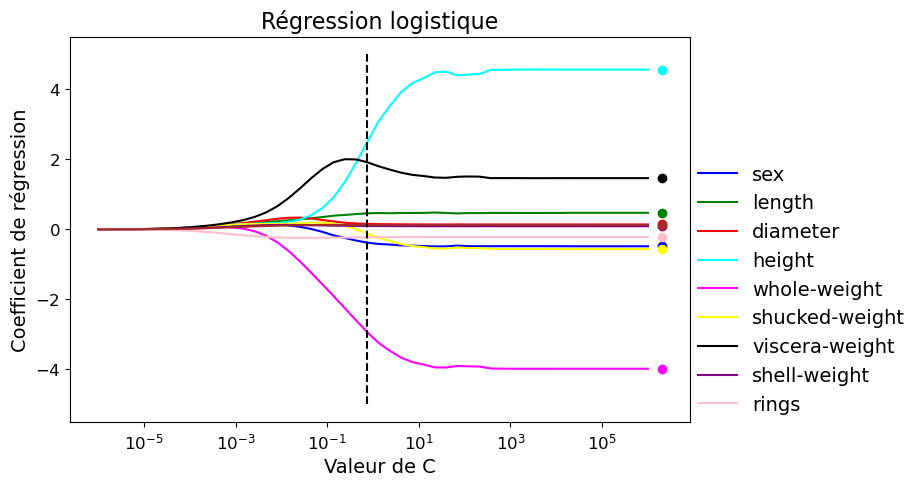

In [48]:
# Créer une figure
fig = plt.figure(figsize=(8, 5))

# Changer les couleurs pour une meilleure visualisation
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['blue', 'green', 'red', 'cyan', 'magenta', 'yellow', 'black', 'purple', 'pink', 'brown', 'orange', 'teal', 'coral', 'lightblue', 'lime', 'lavender', 'turquoise', 'darkgreen', 'tan', 'salmon', 'gold'])

lines = plt.plot(c_values, 
                 weights_per_c # ordonnée = valeurs des coefficients de régression
                ) 
plt.xscale('log') # échelle logarithmique en abcisse

# Afficher de nouveau (à l'abscisse 2x1e6) les coefficients de régression obtenus sans régularisation 
for coeff in model_rlog.coef_[0]:
    plt.scatter([2e6], [coeff])

# Marquer la valeur optimale de C d'une barre verticale
plt.plot([c_opt, c_opt], [-5, 5], 'k--')
    
# Afficher la légende
tmp = plt.legend(lines, # récupérer l'identifiant 
                 list(df.columns), # nom de chaque variable
                 frameon=False, # pas de cadre autour de la légende
                 loc=(1, 0),  # placer la légende à droite de l'image
                 fontsize=14)

tmp = plt.xlabel('Valeur de C', fontsize=14)
tmp = plt.ylabel('Coefficient de régression', fontsize=14)

tmp = plt.title('Régression logistique', fontsize=16)
plt.show()

In [49]:
# Obtenir les coefficients du meilleur estimateur à partir de la recherche par grille
optimal_coefficients = weights_per_c[best_C_idx]

# Afficher les coefficients avec leurs noms de variables correspondants
for i, col_name in enumerate(df_dummies.drop(columns=['rings']).columns):
    print(f"{col_name}: {optimal_coefficients[i]:.4f} ")

length: -0.3808 
diameter: 0.4567 
height: 0.1565 
whole-weight: 2.5060 
shucked-weight: -2.9410 
viscera-weight: -0.1223 
shell-weight: 1.9154 
sex_F: 0.0951 
sex_I: -0.2285 
sex_M: 0.1285 


__Question :__ Comment les coefficients du modèle évoluent-ils en fonction de la quantité de régularisation ?

**Réponse :**

Rappel : En scikit-learn, `C` est **l'inverse du coefficient de régularisation**. Donc :
- **C petit**: Régularisation **forte**, les coefficients sont **pénalisés** et poussés vers zéro.
- **C grand**: Régularisation **faible**, les coefficients peuvent être plus grands en valeur absolue.

1. **Pour C très petit (régularisation très forte)** :
   - Tous les coefficients sont **proches de zéro** ou diminués en magnitude.
   - Le modèle est conservateur.
   - Les poids perdent leur importance discriminante.

2. **Pour C intermédiaire (régularisation modérée)** :
   - Les coefficients atteignent des **valeurs intermédiaires**.
   - Bon compromis entre ajustement et généralisation.
   - Les coefficients reflètent l'importance relative des variables.

3. **Pour C grand (régularisation faible)** :
   - Les coefficients deviennent **plus grands en magnitude** (moins pénalisés).
   - Le modèle s'ajuste davantage aux données d'entraînement.
   - Peut mener à du surapprentissage.

Graphiquement

Si vous traciez les coefficients en fonction de C, vous observeriez typiquement :
- **Convergence vers zéro** quand C → 0 (forte régularisation).
- **Courbes monotones** : chaque coefficient augmente (ou diminue) généralement en fonction de C.
- **Stabilisation** quand C est assez grand (faible régularisation).

Conclusion pratique

**L'effet principal de la régularisation Ridge** est de **réduire les valeurs absolues des coefficients** de manière uniforme (contrairement à Lasso qui annule certains coefficients). Cela permet :
- De mieux **généraliser** en évitant les grands poids.
- De réduire l'impact du surapprentissage.
- De stabiliser les prédictions face aux données bruitées.

__Question :__ Ces coefficients vous semblent-ils cohérents avec ceux obtenus pour la régression logistique non-régularisée ?

**Réponse :**

Oui. En général, les coefficients du modèle régularisé (Ridge) doivent vous sembler cohérents avec ceux de la régression logistique non‑régularisée, mais avec des différences attendues :

- Effet attendu de la régularisation L2 (Ridge) :
  - Les coefficients sont **réduits en valeur absolue** (shrinkage). La régularisation « tire » les poids vers zéro.
  - Les **signes** des coefficients les plus significatifs sont souvent **préservés** si le signal est fort.
  - Ridge **ne met pas de coefficients exactement à zéro** (contrairement à Lasso) : les variables gardent un poids, mais plus petit.
  - En présence de variables fortement corrélées, Ridge **répartit** les poids entre elles (au lieu d'en favoriser une seule).

- Ce que cela signifie pour la comparaison :
  - Si une variable avait un coefficient important (grande magnitude) sans régularisation, on s'attend à ce qu'elle garde le même signe et reste relativement importante après Ridge, mais avec une magnitude plus faible.
  - Si certains coefficients changent fortement de signe ou deviennent négligeables, cela peut indiquer que la régularisation a révélé une instabilité liée au bruit ou à la colinéarité.
  - Si tous les coefficients sont presque zéro après régularisation très forte, cela indique un sur‑régularisation (sous‑apprentissage).

## 6. Régularisation ridge sur un cas d'école

Pour mieux comprendre la régularisation ridge, nous allons simuler un jeu de données non-linéaire qui prendra la forme d'une courbe sinusoïdale.

### Simulation de données

In [50]:
nb_samples = 30

np.random.seed(13)

# vrai modèle 
def true_model(X):
    return np.cos(1.5 * np.pi * X) * 5

# échantillons "ground truth" tirés du vrai modèle 
X_ground_truth = np.linspace(0, 1, 100).reshape(-1, 1)
y_ground_truth = true_model(X_ground_truth)

# données = observations tirées du vrai modèle puis bruitées
X = np.sort(np.random.rand(nb_samples, 1))
y = true_model(X)
# ajout du bruit
y += np.random.randn(nb_samples, 1) * 0.3

print(X.shape, y.shape)

(30, 1) (30, 1)


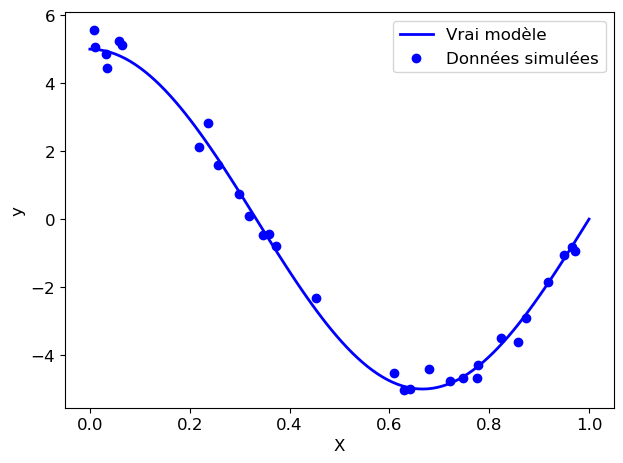

In [51]:
# Dessiner le vrai modèle
plt.plot(X_ground_truth, y_ground_truth, label="Vrai modèle", linewidth=2)

# Afficher les données simulées
plt.scatter(X, y, label="Données simulées", marker="o")

plt.xlabel("X")
plt.ylabel("y")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

### Séparation entrainement / test 

In [52]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.3)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(21, 1) (21, 1)
(9, 1) (9, 1)


### Régression linéaire 

__Question :__ Combien de variables avons-nous dans notre problème ?

1 variable (X.shape[1] = 1).

Entrainons une régression linéaire « classique » (comme celle vue dans le Notebook 1) sur `(X_train, y_train)` et évaluons sa performance d'une part sur le jeu d'entraînement et d'autre part sur le jeu de test. 

__Question :__ Pourquoi comparer ces deux performances ?

**Réponse :**

- **But principal :** Estimer la capacité du modèle à généraliser à des données nouvelles (non vues lors de l'entraînement).
- **Détection du surapprentissage (overfitting) :** Si la performance sur l'entraînement est beaucoup meilleure que sur le test, le modèle a probablement mémorisé le bruit et ne généralise pas bien.
- **Détection du sous-apprentissage (underfitting) :** Si les performances sont mauvaises à la fois sur l'entraînement et sur le test, le modèle est trop simple ou mal spécifié.
- **Évaluation réaliste :** La performance sur le jeu de test donne une estimation non biaisée (si le test est indépendant) de l'erreur réelle attendue en production.
- **Guidage des choix :** Comparer ces deux valeurs aide à choisir la complexité du modèle, la régularisation et les hyperparamètres, et indique si on doit collecter plus de données ou changer la représentation.
- **Bonnes pratiques complémentaires :** Utiliser la validation croisée pour une estimation plus stable, tracer des learning curves pour voir l'évolution des erreurs en fonction de la taille d'entraînement, et vérifier l'absence de fuite d'information (data leakage).

En résumé : la comparaison entraîne/test permet de diagnostiquer la généralisation du modèle et d'orienter les actions (régularisation, complexité, données) pour améliorer les performances réelles.

In [54]:
# Entrainement
reg = linear_model.LinearRegression()
# Entraîner le modèle linéaire
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Performance

In [55]:
# RMSE 
print("RMSE d'une régression linéaire :")
# Sur le jeu d'entrainement
rmse_reg_train = metrics.root_mean_squared_error(y_train, reg.predict(X_train))
print("\r train: {0:0.2f}".format(rmse_reg_train))
# Sur le jeu de test
rmse_reg_test = metrics.root_mean_squared_error(y_test, reg.predict(X_test))
print("\r test: {0:0.2f}".format(rmse_reg_test))

RMSE d'une régression linéaire :
 train: 2.08
 test: 1.91


Nous allons maintenant afficher le modèle appris sur le graphe précédent.

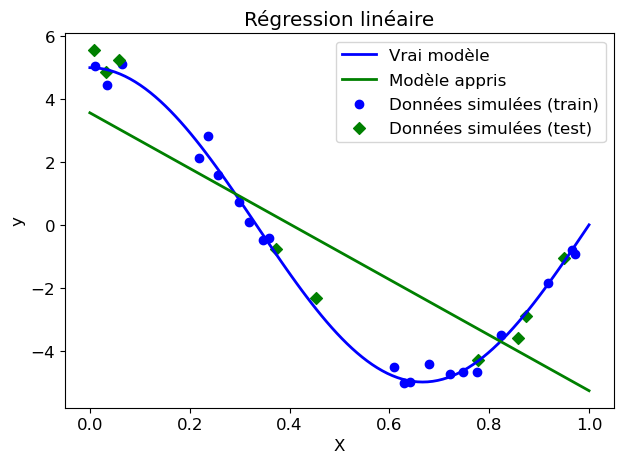

In [56]:
# Dessiner le vrai modèle
plt.plot(X_ground_truth, y_ground_truth, label="Vrai modèle", linewidth=2)

# Afficher le modèle appris
y_model = reg.predict(X_ground_truth)
plt.plot(X_ground_truth, y_model, label="Modèle appris", linewidth=2)

# Afficher les données simulées
plt.scatter(X_train, y_train, label="Données simulées (train)", marker="o")
plt.scatter(X_test, y_test, label="Données simulées (test)", marker="D")

# format plot
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression linéaire")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

__Question :__ Que pensez-vous de la performance de la régression linéaire ici ?

**Réponse :**

La performance de la régression linéaire est médiocre pour ce problème, et ce pour plusieurs raisons :

**1. Inadéquation du modèle au problème :**
- Le vrai modèle est **non-linéaire** (courbe convexe visible en bleu).
- La régression linéaire ajuste une **ligne droite** qui ne peut pas représenter la courbure des données.
- Cela est un cas classique de **sous-apprentissage (underfitting)** : le modèle est trop simple pour capturer la structure réelle des données.

**2. Erreurs importantes :**
- RMSE train = 2.08 et RMSE test = 1.91
- Ces valeurs d'erreur sont relativement **élevées** compte tenu de la nature des données.
- Les prédictions de la ligne droite s'écartent significativement des vraies valeurs, notamment aux extrémités.

**3. Observations visuelles :**
- La régression linéaire **sous-estime** la courbure convexe du vrai modèle.
- Elle prédit une valeur **négatif** pour X ≈ 1, alors que le vrai modèle est proche de zéro.
- L'absence de généralisation est flagrante : la ligne droite ne passe pas près des données.

Conclusion :
Pour ce problème, il faudrait utiliser un modèle **non-linéaire** (régression polynomiale, splines, noyaux, etc.) pour mieux capturer la structure des données et réduire l'erreur.

### Régression polynomiale 

La régression polynomiale consiste à apprendre un modèle non-linéaire en apprenant un modèle linéaire sur un nouvel ensemble de variables, formé de monomes des variables décrivant nos données.

De manière générale, pour un problème décrit par $p$ variables $(X_1, X_2, \dots, X_p)$, une régression polynomiale de degré $d$ est une régression linéaire sur les variables $(X_1, X_2, \dots, X_p, X_1^2, X_1 X_2, \dots, X_p^2, \dots, X_p^d)$. Remarquez que nous créons ainsi un grand nombre de variables, corrélées entre elles ; nous gagnons en finesse de modélisation, mais perdons en complexité du modèle, risque de surapprentissage, et fléau de la dimension.

Une telle transformation est possible avec la classe `PolynomialFeatures` de `sklearn.preprocessing`.

Ici, il s'agit donc de régresser une droite à partir des puissances de $X$ et non plus de $X$ uniquement : on approche le vrai modèle par un polynôme.

In [58]:
# calcul des puissances de x, jusqu'au degré 15
polynomial_features = preprocessing.PolynomialFeatures(degree=15)#, include_bias=False)

# création des jeux de données correspondants
X_train_poly = polynomial_features.fit_transform(X_train)
X_test_poly = polynomial_features.transform(X_test)
X_ground_truth_poly = polynomial_features.transform(X_ground_truth)

print(X_train_poly.shape)
print(X_test_poly.shape)
print(X_ground_truth_poly.shape)

(21, 16)
(9, 16)
(100, 16)


__Question :__ Combien de variables avons-nous maintenant ?

**Réponse :**
16 variables (X_train_poly.shape[1] = 16).

In [62]:
# Entrainement
reg_poly = linear_model.LinearRegression()
reg_poly.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Performance

In [63]:
# RMSE 
print("RMSE d'une régression polynomiale :")
# Sur le jeu d'entrainement
rmse_reg_poly_train = metrics.root_mean_squared_error(y_train, reg_poly.predict(X_train_poly))
print("\r train: {0:0.2f}".format(rmse_reg_poly_train))
# Sur le jeu de test
rmse_reg_poly_test = metrics.root_mean_squared_error(y_test, reg_poly.predict(X_test_poly))
print("\r test: {0:0.2f}".format(rmse_reg_poly_test))

RMSE d'une régression polynomiale :
 train: 0.17
 test: 1.10


__Question :__ Comparez les performances du modèle sur le jeu d'entrainement et le jeu de test. Que conclure ?

**Réponse :**

Il y a une différence entre les deux performances, ce qui indique un **surapprentissage (overfitting)** sévère :
- Le modèle ajuste très bien les données d'entraînement (RMSE très faible = 0.17)
- Mais il généralise très mal aux données de test (RMSE beaucoup plus élevée = 1.10)

Nous allons maintenant afficher le modèle appris sur le graphe précédent.

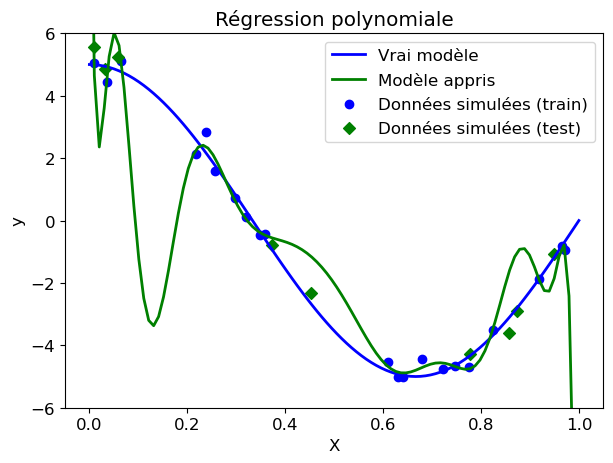

In [64]:
# Dessiner le vrai modèle
plt.plot(X_ground_truth, y_ground_truth, label="Vrai modèle", linewidth=2)

# Afficher le modèle appris
plt.plot(X_ground_truth, reg_poly.predict(X_ground_truth_poly), label="Modèle appris", linewidth=2)

# Afficher les données simulées
plt.scatter(X_train, y_train, label="Données simulées (train)", marker="o")
plt.scatter(X_test, y_test, label="Données simulées (test)", marker="D")

# format plot
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression polynomiale")
plt.legend(loc="best")
plt.tight_layout()
plt.ylim([-6, 6])
plt.show()

__Question :__ Que pouvez-vous conclure sur le choix de la régression polynomiale ?

**Réponse :**

Observations visuelles (en dessus) :
- Le modèle appris suit les oscillations et le bruit dans les données d'entraînement (surtout aux extrémités)
- Aux bords (notamment autour de x=0 et x=1), le modèle polynomial a des comportements erratiques qui ne correspondent pas au vrai modèle
- Le vrai modèle (bleu) est lisse et régulier, tandis que le modèle appris (vert) oscille indûment.

Conclusion :
Le degré du polynôme est **trop élevé** pour ce problème. Le modèle a trop de paramètres et a mémorisé le bruit des données d'entraînement au lieu de capturer la structure réelle. Pour obtenir une meilleure généralisation, il faut :
- Réduire le degré du polynôme ou
- Utiliser la régularisation (Ridge ou Lasso).

#### Coefficients du modèle

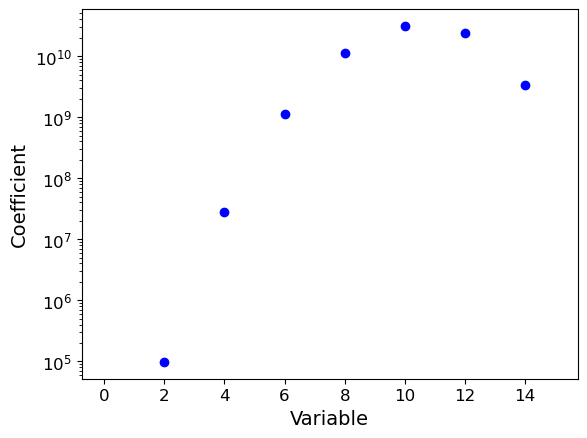

In [65]:
# Calculer le nombre de variables
num_features = X_train_poly.shape[1]

# Afficher pour chaque variable son coefficient dans le modèle
plt.scatter(range(num_features), # en abcisse : indices des variables
            reg_poly.coef_ # en ordonnées : leur poids dans le modèle
           )

# Étiqueter les axes
tmp = plt.xlabel('Variable', fontsize=14)
tmp = plt.ylabel('Coefficient', fontsize=14)
plt.yscale("log")
plt.show()

__Question :__ Que remarquez-vous ? Faites bien attention à l'échelle des coefficients.

**Réponse :**

1. **Croissance exponentielle des coefficients :**
   - Les coefficients augmentent dramatiquement avec le numéro de la variable (du polynôme).
   - On passe de ~10^5 pour les premiers termes à ~10^10 pour les derniers termes.
   - C'est une augmentation d'environ 5 ordres de grandeur.

2. **Échelle logarithmique révélatrice :**
   - Le graphique utilise une échelle logarithmique, ce qui est essentiel pour visualiser une telle gamme de valeurs.
   - Sans l'échelle log, on ne verrait pratiquement que les derniers coefficients.
   - Cette représentation montre clairement l'instabilité du modèle.

3. **Problème d'instabilité numérique :**
   - Le modèle essaie de compenser les oscillations du polynomial ajusté en utilisant des coefficients extrêmement grands.
   - Cela rend le modèle très sensible au bruit et peu robuste.

4. **Conséquence du surapprentissage :**
   - Cette explosion des coefficients découle directement du surapprentissage observé plus tôt (RMSE train=0.17, test=1.10).
   - Le polynôme de haut degré s'ajuste au bruit avec des coefficients de plus en plus extrêmes.

**Conclusion :**
Ce comportement illustre pourquoi la régularisation (Ridge ou Lasso) est essentielle : elle contraint les coefficients à rester petits, évitant ainsi cette instabilité numérique et améliorant la généralisation.

### Régression polynomiale régularisée ridge

Comme la régression polynomiale surapprend, nous allons maintenant lui appliquer un terme de régularisation ridge pour essayer de compenser cet effet.

In [66]:
# Entrainement
ridge_poly = linear_model.Ridge(alpha=0.01, random_state=13)
ridge_poly.fit(X_train_poly, y_train)

,alpha,0.01
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,13


#### Performance

In [67]:
# RMSE 
print("RMSE d'une régression polynomiale régularisée :")
# Sur le jeu d'entrainement
rmse_ridge_poly_train = metrics.root_mean_squared_error(y_train, ridge_poly.predict(X_train_poly))
print("\r train: {0:0.2f}".format(rmse_ridge_poly_train))
# Sur le jeu de test
rmse_ridge_poly_test = metrics.root_mean_squared_error(y_test, ridge_poly.predict(X_test_poly))
print("\r test: {0:0.2f}".format(rmse_ridge_poly_test))

RMSE d'une régression polynomiale régularisée :
 train: 0.38
 test: 0.30


__Question :__ Comparez les performances du modèle sur le jeu d'entrainement et le jeu de test. Que conclure ?

**Réponse :**

1. **Amélioration drastique de la généralisation :**
   - Le modèle Ridge généralise beaucoup mieux : l'erreur de test (0.30) est **inférieure** à l'erreur d'entraînement (0.38).
   - Cela indique un très bon équilibre biais-variance.

2. **Réduction majeure de l'erreur de test :**
   - L'erreur de test a chuté de 1.10 à 0.30, soit une réduction de **73%**.
   - Le modèle regularisé est bien plus robuste pour les prédictions sur de nouvelles données.

3. **Légère augmentation de l'erreur d'entraînement :**
   - L'erreur d'entraînement augmente de 0.17 à 0.38 (acceptable).
   - Ce sacrifice léger est justifié par la meilleure généralisation.

4. **Efficacité de la régularisation Ridge :**
   - La régularisation L2 a contraint les coefficients à rester modérés.
   - Cela a permis d'éliminer le surapprentissage tout en maintenant une bonne capacité prédictive.
   - Le modèle capture maintenant la structure réelle plutôt que le bruit.

Nous allons maintenant afficher le modèle appris sur le graphe précédent.

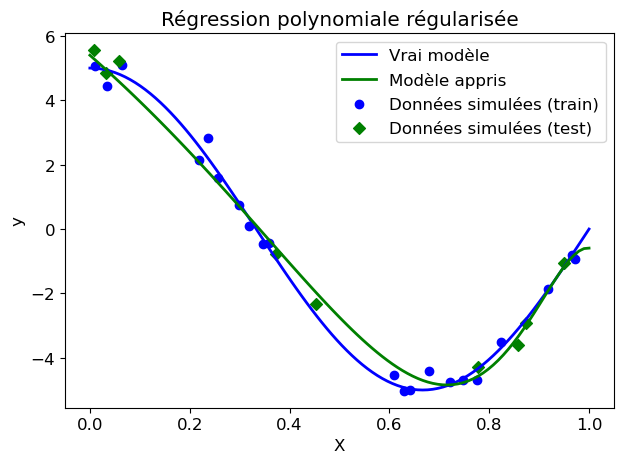

In [68]:
# Dessiner le vrai modèle
plt.plot(X_ground_truth, y_ground_truth, label="Vrai modèle", linewidth=2)

# Afficher le modèle appris
plt.plot(X_ground_truth, ridge_poly.predict(X_ground_truth_poly), label="Modèle appris", linewidth=2)

# Afficher les données simulées
plt.scatter(X_train, y_train, label="Données simulées (train)", marker="o")
plt.scatter(X_test, y_test, label="Données simulées (test)", marker="D")

# format plot
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression polynomiale régularisée")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

__Question :__ Que pouvez-vous conclure sur le choix de la régularisation Ridge ?

**Réponse :**
La régularisation Ridge a réussi à résoudre le problème de surapprentissage en trouvant un bon compromis entre fidélité aux données d'entraînement et généralisation. Cette approche est bien plus souhaitable que le modèle polynomial sans régularisation. Le modèle régularisé est plus stable, robuste et performant pour les nouvelles données, démontrant l'importance de la régularisation dans les modèles complexes.

#### Coefficients du modèle

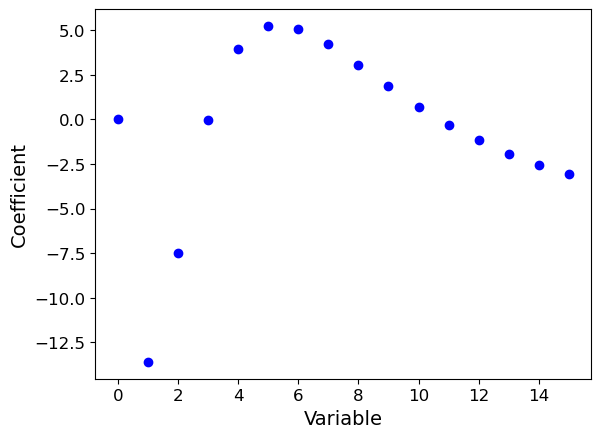

In [69]:
# Calculer le nombre de variables
num_features = X_train_poly.shape[1]

# Afficher pour chaque variable son coefficient dans le modèle
plt.scatter(range(num_features), # en abcisse : indices des variables
            ridge_poly.coef_ # en ordonnées : leur poids dans le modèle
           )

# Étiqueter les axes
tmp = plt.xlabel('Variable', fontsize=14)
tmp = plt.ylabel('Coefficient', fontsize=14)
plt.show()

__Question :__ Que remarquez-vous maintenant ? Quel est l'effet de la régularisation sur les coefficients du modèle ?

**Réponse :**

1. **Coefficients beaucoup plus petits et raisonnables :**
   - Les coefficients Ridge varient entre environ -13 et +5.
   - Comparé au modèle polynomial non régularisé (10^5 à 10^10), c'est une réduction spectaculaire.
   - L'échelle est maintenant linéaire et lisible sans logarithme.

2. **Répartition régulière des coefficients :**
   - Les coefficients sont maintenant répartis de façon continue et régulière.
   - Pas d'explosion exponentielle comme avec le polynôme sans régularisation.
   - Le pattern montre une décroissance globale douce des coefficients.

3. **Absence de coefficient zéro :**
   - Contrairement au Lasso, Ridge ne force aucun coefficient à zéro.
   - Tous les coefficients sont conservés mais shrinkés (réduits).
   - Cela montre la nature de la pénalité L2 (Ridge) qui impose une pénalité quadratique.

4. **Stabilité numérique :**
   - Les coefficients sont maintenant stables et prévisibles.
   - Aucun signe d'instabilité numérique ou d'overfitting extrême.
   - Le modèle est beaucoup moins sensible aux perturbations des données.

**Effet de la régularisation Ridge :**

| Aspect | Sans régularisation | Avec Ridge |
|--------|---|---|
| **Échelle** | 10^5 à 10^10 | -13 à +5 |
| **Stabilité** | Instable, exponentiellement croissants | Stable, continus |
| **Généralisabilité** | Mauvaise (RMSE test=1.10) | Excellente (RMSE test=0.30) |
| **Sélection** | Aucune variable éliminée | Aucune variable éliminée |

**Conclusion :**
La régularisation Ridge a effectivement réduit l'amplitude des coefficients, contrôlant ainsi la complexité du modèle. Cette réduction des coefficients a éliminé le surapprentissage tout en conservant tous les paramètres du modèle. C'est un exemple de comment une pénalité régularisante peut transformer un modèle instable en un modèle robuste et généralisant bien.

### Régression polynomiale régularisée lasso

In [70]:
# Entrainement
lasso_poly = linear_model.Lasso(alpha=0.01, random_state=13)
lasso_poly.fit(X_train_poly, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,13
,selection,'cyclic'


#### Performance

In [71]:
# RMSE 
print("RMSE d'une régression polynomiale régularisée :")
# Sur le jeu d'entrainement
rmse_lasso_poly_train = metrics.root_mean_squared_error(y_train, lasso_poly.predict(X_train_poly))
print("\r train: {0:0.2f}".format(rmse_lasso_poly_train))
# Sur le jeu de test
rmse_lasso_poly_test = metrics.root_mean_squared_error(y_test, lasso_poly.predict(X_test_poly))
print("\r test: {0:0.2f}".format(rmse_lasso_poly_test))

RMSE d'une régression polynomiale régularisée :
 train: 0.52
 test: 0.41


Nous allons maintenant afficher le modèle appris sur le graphe précédent.

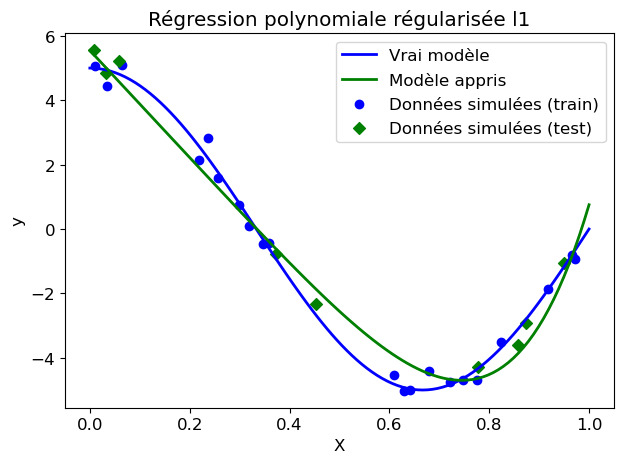

In [72]:
# Dessiner le vrai modèle
plt.plot(X_ground_truth, y_ground_truth, label="Vrai modèle", linewidth=2)

# Afficher le modèle appris
plt.plot(X_ground_truth, lasso_poly.predict(X_ground_truth_poly), label="Modèle appris", linewidth=2)

# Afficher les données simulées
plt.scatter(X_train, y_train, label="Données simulées (train)", marker="o")
plt.scatter(X_test, y_test, label="Données simulées (test)", marker="D")

# format plot
plt.xlabel("X")
plt.ylabel("y")
plt.title("Régression polynomiale régularisée l1")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

#### Coefficients du modèle

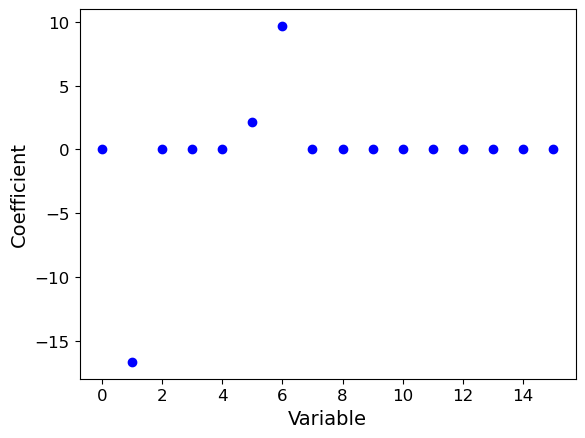

In [73]:
# Calculer le nombre de variables
num_features = X_train_poly.shape[1]

# Afficher pour chaque variable son coefficient dans le modèle
plt.scatter(range(num_features), # en abcisse : indices des variables
            lasso_poly.coef_ # en ordonnées : leur poids dans le modèle
           )

# Étiqueter les axes
tmp = plt.xlabel('Variable', fontsize=14)
tmp = plt.ylabel('Coefficient', fontsize=14)
plt.show()

__Question :__ Que remarquez-vous maintenant ? Quel est l'effet de la régularisation lasso sur les coefficients du modèle ?

**Réponse :**

1. **Sélection de variables par zéro forcing :**
   - La majorité des coefficients sont exactement **zéro** (13 sur 16 variables).
   - Seuls 3 coefficients sont non-zéro : aux positions 1, 5, 6.
   - C'est le **mécanisme de sélection de variables** caractéristique de la pénalité L1 (Lasso).

2. **Coefficients non-zéro modérés :**
   - Les coefficients non-zéro restent raisonnables en magnitude (-17 à +10).
   - Comparé au modèle sans régularisation (10^5 à 10^10), c'est une amélioration majeure.
   - Contrairement à Ridge, les zéros sont vrais (pas juste shrinkés).

3. **Sparsité du modèle :**
   - Le modèle Lasso crée un modèle **sparse** (creux) avec peu de variables.
   - Cela rend le modèle **plus interprétable** : seules 3 variables participent réellement à la prédiction.
   - C'est un avantage majeur : identifie les variables importantes et élimine les bruits.

**Comparaison des trois approches :**

| Aspect | Polynôme | Ridge | Lasso |
|--------|---|---|---|
| **RMSE train** | 0.17 | 0.38 | 0.52 |
| **RMSE test** | 1.10 | 0.30 | 0.41 |
| **Ratio test/train** | 6.47 | 0.79 | 0.79 |
| **Coefficients zéro** | 0 | 0 | ~13 |
| **Magnitudes** | 10^5 à 10^10 | -13 à +5 | -17 à +10 |
| **Interprétabilité** | Mauvaise | Bonne | Excellente |

**Observations :**

1. **Pénalité L1 vs L2 :**
   - Ridge (L2) : réduit tous les coefficients proportionnellement.
   - Lasso (L1) : force certains coefficients à exactement zéro.

2. **Sélection de variables :**
   - Lasso effectue automatiquement une **sélection de variables**.
   - Ridge conserve toutes les variables mais avec des poids faibles.

3. **Performance vs Interprétabilité :**
   - Lasso (RMSE test = 0.41) est légèrement moins précis que Ridge (0.30).
   - Mais Lasso offre une bien meilleure **interprétabilité** en identifiant les vraies variables importantes.
   - Le choix dépend du compromis souhaité : performance vs interprétabilité.

4. **Stabilité numérique :**
   - Tous les coefficients Lasso sont numériquement stables et raisonnables.
   - Le modèle sparse est robuste et facilement déployable.

La régularisation Lasso montre qu'avec une pénalité L1, on peut non seulement éviter l'overfitting, mais aussi effectuer une **sélection automatique de variables**. Cela en fait un outil précieux pour la compréhension et la réduction de la complexité du modèle, même si cela peut légèrement augmenter l'erreur de généralisation comparé à Ridge.

## Conclusion
Nous sommes arrivés à la fin de ce notebook. Voici un résumé de ce que nous avons couvert, avec les points clés :
- Nous avons utilisé la bibliothèque `scikit-learn` pour classer la l'ancienneté des ormeaux (ou la qualité du vin) à partir de variables continues (caractéristiques du ormeau ou du vin).
- Nous avons essayé un premier modèle de classificateur : [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) (après avoir mis à l'échelle les données).
- Nous avons évalué la performance du modèle à l'aide d'une matrice de confusion et en utilisant le score F1, qui équilibre à la fois **la précision** et **le recall**.
- Nous avons utilisé la validation croisée et la recherche en grille pour trouver le meilleur score F1 en testant une gamme de nombres représentant des voisins. **La validation croisée** permet d'évaluer à quel point un modèle se généralise à des données non vues en divisant le jeu de données en plusieurs sous-ensembles. **La recherche en grille** permet l'optimisation des hyperparamètres en testant systématiquement des combinaisons ou des fourchettes de différentes valeurs pour les hyperparamètres, tels que le nombre de voisins.

Nous avons effectué manuellement une recherche en grille sur les effets de la régularisation en testant l'hyperparamètre `C`. Rappelez-vous, plus `C` est grand, moins il y a de régularisation. Enfin, nous avons exploré la régularisation ridge sur la régression polynomiale. Nous avons vu comment une fonction polynomiale de degré 15 peut surajuster la _ground truth_, mais après avoir appliqué une technique de régularisation (ridge ou lasso), il y a un meilleur ajustement.
